# LOADING DATA

In [61]:
import pandas as pd
df_census = pd.read_csv('/Users/preciousajilore/Documents/GitHub/BDG/Datasets/ADA_profile_simplified.csv')
df_census.head()
df_census.columns

Index(['CMANAME', 'CMAUID', 'CSDNAME', 'CSDUID', 'PRNAME', 'ada_code_n',
       'ADA_code', 'T1527', 'T1528', 'T1529',
       ...
       'W1673', 'W1674', 'W1675', 'W1676', 'W1677', 'W1678', 'W1679', 'W1680',
       'W1681', 'W1682'],
      dtype='object', length=319)

In [62]:
df_access = pd.read_csv('/Users/preciousajilore/Documents/GitHub/BDG/Datasets/ADA_acs_file.csv', encoding='latin1', skiprows=1)
df_access.head()

,CMANAME,CMAUID,CSDNAME,CSDUID,public_caf,public_ef,public_emp,public_gs,public_hf,public_psef,public_srf,walk_caf,walk_ef,walk_emp,walk_gs,walk_hf,walk_psef,walk_srf,ada_code_n,ADA_code
0,Weak metropolitan influenced zone (N.L.) / Zon...,998,Old Perlican,1001343,0.000000,0.000000,0.000000,NaN,0.000000,0.000000,0.000000,0.000926,0.000754,0.000046,1.791493,0.000015,0.000000,0.000459,10010001,10010001
1,St. John's,1,Pouch Cove,1001505,0.000000,0.000000,0.000000,NaN,0.000000,0.000000,0.000000,0.001482,0.000000,0.000351,NaN,0.000153,0.000000,0.003352,10010002,10010002
2,Weak metropolitan influenced zone (N.L.) / Zon...,998,"Division No. 1, Subd. I",1001374,0.000000,0.000000,0.000000,NaN,0.000000,0.000000,0.000000,0.005042,0.001006,0.001342,5.560567,0.001283,0.013029,0.001829,10010003,10010003
3,St. John's,1,St. John's,1001519,0.008549,0.008819,0.008912,24.173913,0.008047,0.016364,0.011867,0.003519,0.028732,0.010999,5.638327,0.019479,0.026563,0.030279,10010004,10010004
4,St. John's,1,Torbay,1001509,0.000000,0.000000,0.000131,NaN,0.000138,0.000000,0.000175,0.002472,0.005695,0.001651,4.934948,0.002003,0.000000,0.004962,10010005,10010005


In [63]:
merged = pd.merge(df_census, df_access, on='ADA_code', how='inner')
merged.head()

,CMANAME_x,CMAUID_x,CSDNAME_x,CSDUID_x,PRNAME,ada_code_n_x,ADA_code,T1527,T1528,T1529,...,public_psef,public_srf,walk_caf,walk_ef,walk_emp,walk_gs,walk_hf,walk_psef,walk_srf,ada_code_n_y
0,Moderate metropolitan influenced zone (N.L.) /...,997,"Division No. 1, Subd. E",1001304,Newfoundland and Labrador / Terre-Neuve-et-Lab...,10010001,10010001,8790.0,8685.0,100.0,...,0.000000,0.000000,0.000926,0.000754,0.000046,1.791493,0.000015,0.000000,0.000459,10010001
1,St. John's,1,Pouch Cove,1001505,Newfoundland and Labrador / Terre-Neuve-et-Lab...,10010002,10010002,4195.0,4145.0,40.0,...,0.000000,0.000000,0.001482,0.000000,0.000351,NaN,0.000153,0.000000,0.003352,10010002
2,Weak metropolitan influenced zone (N.L.) / Zon...,998,"Division No. 1, Subd. I",1001374,Newfoundland and Labrador / Terre-Neuve-et-Lab...,10010003,10010003,10715.0,10500.0,190.0,...,0.000000,0.000000,0.005042,0.001006,0.001342,5.560567,0.001283,0.013029,0.001829,10010003
3,St. John's,1,St. John's,1001519,Newfoundland and Labrador / Terre-Neuve-et-Lab...,10010004,10010004,9960.0,8805.0,935.0,...,0.016364,0.011867,0.003519,0.028732,0.010999,5.638327,0.019479,0.026563,0.030279,10010004
4,St. John's,1,Portugal Cove-St. Philip's,1001504,Newfoundland and Labrador / Terre-Neuve-et-Lab...,10010005,10010005,9385.0,9130.0,245.0,...,0.000000,0.000175,0.002472,0.005695,0.001651,4.934948,0.002003,0.000000,0.004962,10010005


In [64]:
columns = [
    'ADA_code',   # Geographic area code
    'T1537',      # Non-permanent residents
    'T1581',      # Nigerian-born immigrants
    'T1539',      # Under 5 years
    'T1540',      # 5 to 14 years
    'T1541',      # 15 to 24 years
    'T1542',      # 25 to 44 years
    'T1543',      # 45 years and over
    'T1676',      # Total - Pre-admission experience
    'T1677',      # Asylum claim before admission
    'T1678',      # Work permits only before admission
    'T1679',      # Study permits only before admission
    'T1680',      # Work and study permits before admission
    'T1681',      # Other permits before admission
    'T1682',      # No pre-admission experience
    'public_psef', 'walk_psef',  # Post secondary education
    'public_hf', 'walk_hf'      # Healthcare
]

# FULL DATASET FOR MIGRANTS

In [65]:
merged_clean = merged.dropna()
merged_clean.head()

,CMANAME_x,CMAUID_x,CSDNAME_x,CSDUID_x,PRNAME,ada_code_n_x,ADA_code,T1527,T1528,T1529,...,public_psef,public_srf,walk_caf,walk_ef,walk_emp,walk_gs,walk_hf,walk_psef,walk_srf,ada_code_n_y
3,St. John's,1,St. John's,1001519,Newfoundland and Labrador / Terre-Neuve-et-Lab...,10010004,10010004,9960.0,8805.0,935.0,...,0.016364,0.011867,0.003519,0.028732,0.010999,5.638327,0.019479,0.026563,0.030279,10010004
5,St. John's,1,St. John's,1001519,Newfoundland and Labrador / Terre-Neuve-et-Lab...,10010006,10010006,8035.0,6950.0,810.0,...,0.024708,0.031566,0.010677,0.048295,0.014439,5.979807,0.027316,0.031713,0.048840,10010006
6,St. John's,1,St. John's,1001519,Newfoundland and Labrador / Terre-Neuve-et-Lab...,10010007,10010007,7730.0,7065.0,480.0,...,0.011684,0.012513,0.002056,0.009008,0.011531,7.826365,0.008619,0.000000,0.012105,10010007
7,St. John's,1,St. John's,1001519,Newfoundland and Labrador / Terre-Neuve-et-Lab...,10010008,10010008,5725.0,5105.0,485.0,...,0.016956,0.018556,0.005800,0.041214,0.015662,5.300723,0.030807,0.002606,0.040633,10010008
8,St. John's,1,St. John's,1001519,Newfoundland and Labrador / Terre-Neuve-et-Lab...,10010009,10010009,8545.0,7420.0,670.0,...,0.037530,0.048399,0.067870,0.057615,0.041348,2.621495,0.051164,0.007668,0.090763,10010009


# VISUALIZATIONS

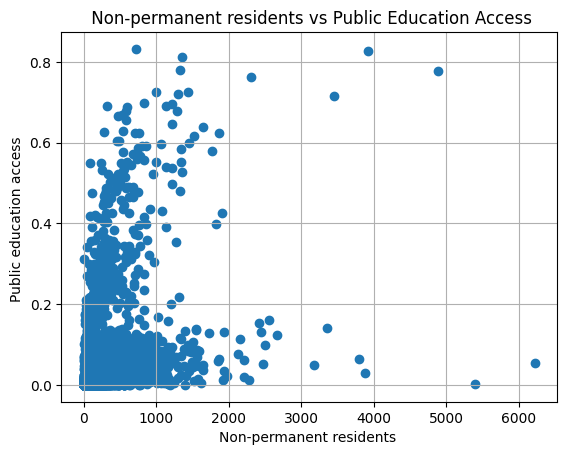

In [66]:

import matplotlib.pyplot as plt
plt.scatter(merged['T1537'], merged['public_psef'])
plt.xlabel('Non-permanent residents ')
plt.ylabel('Public education access ')
plt.title(' Non-permanent residents vs Public Education Access')
plt.grid(True)
plt.show()

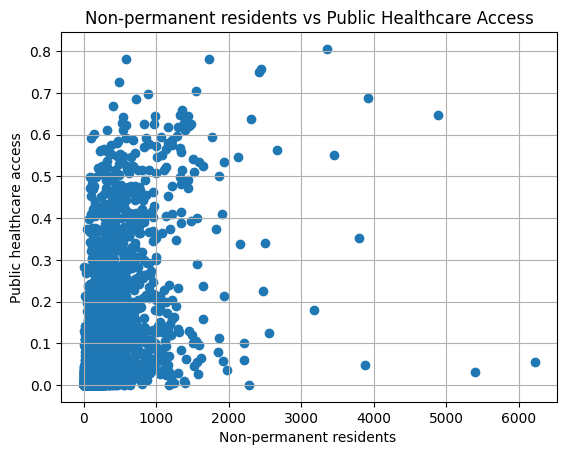

In [67]:
plt.scatter(merged['T1537'], merged['public_hf'])
plt.xlabel('Non-permanent residents ')
plt.ylabel('Public healthcare access')
plt.title('Non-permanent residents vs Public Healthcare Access')
plt.grid(True)
plt.show()

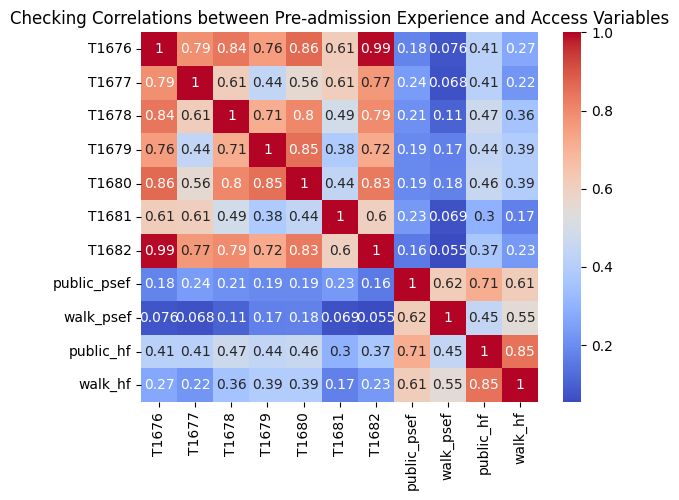

In [68]:
import seaborn as sns
pre_admission_cols = [
    'T1676', 'T1677', 'T1678', 'T1679', 'T1680', 'T1681', 'T1682',
    'public_psef', 'walk_psef', 'public_hf', 'walk_hf'
]

corr_pre_adm = merged[pre_admission_cols].corr()

sns.heatmap(corr_pre_adm, annot=True,cmap = 'coolwarm' )
plt.title('Checking Correlations between Pre-admission Experience and Access Variables')
plt.show()


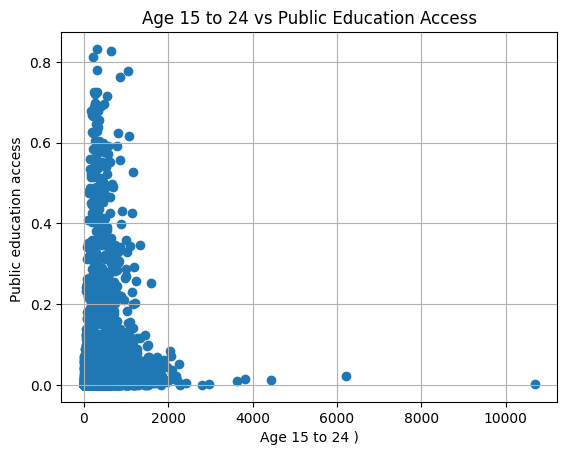

In [69]:
#Checking for relationships between age and access
plt.scatter(merged['T1541'], merged['public_psef'])
plt.xlabel('Age 15 to 24 )')
plt.ylabel('Public education access ')
plt.title('Age 15 to 24 vs Public Education Access')
plt.grid(True)
plt.show()

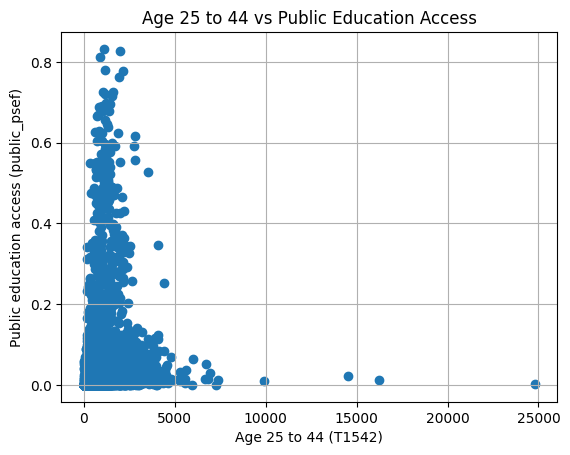

In [70]:
plt.scatter(merged['T1542'], merged['public_psef'])
plt.xlabel('Age 25 to 44 (T1542)')
plt.ylabel('Public education access (public_psef)')
plt.title('Age 25 to 44 vs Public Education Access')
plt.grid(True)
plt.show()

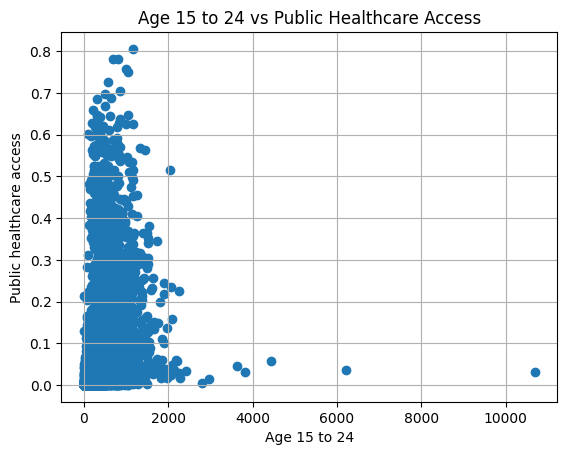

In [71]:
plt.scatter(merged['T1541'], merged['public_hf'])
plt.xlabel('Age 15 to 24')
plt.ylabel('Public healthcare access')
plt.title('Age 15 to 24 vs Public Healthcare Access')
plt.grid(True)
plt.show()

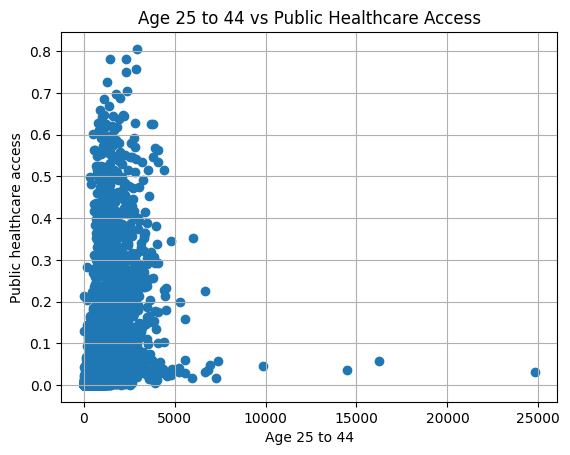

In [72]:
plt.scatter(merged['T1542'], merged['public_hf'])
plt.xlabel('Age 25 to 44')
plt.ylabel('Public healthcare access')
plt.title('Age 25 to 44 vs Public Healthcare Access')
plt.grid(True)
plt.show()

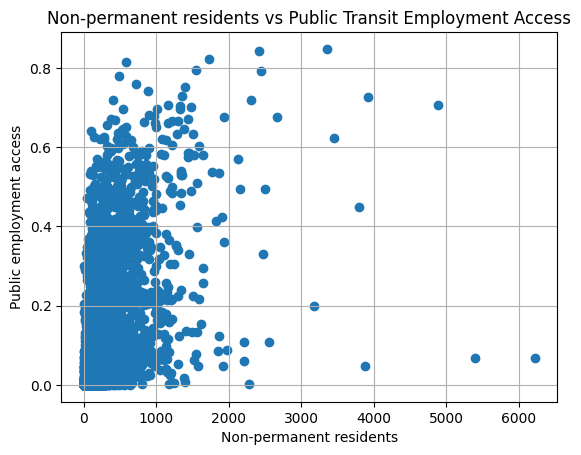

In [73]:
plt.scatter(merged['T1537'], merged['public_emp'])
plt.xlabel('Non-permanent residents')
plt.ylabel('Public employment access')
plt.title('Non-permanent residents vs Public Transit Employment Access')
plt.grid(True)
plt.show()

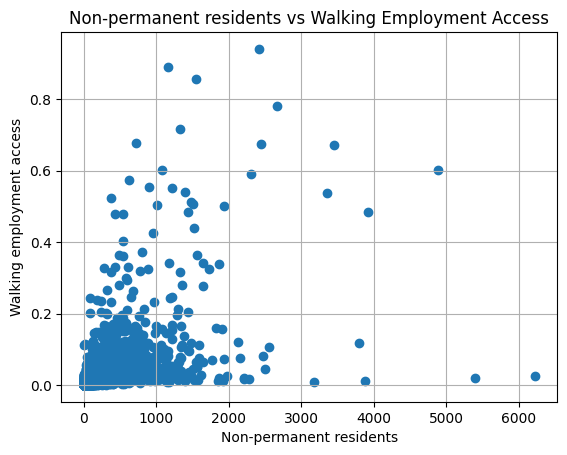

In [74]:
plt.scatter(merged['T1537'], merged['walk_emp'])
plt.xlabel('Non-permanent residents')
plt.ylabel('Walking employment access')
plt.title('Non-permanent residents vs Walking Employment Access')
plt.grid(True)
plt.show()

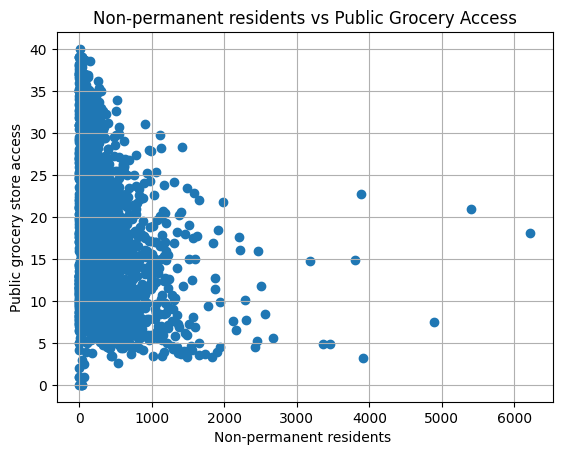

In [75]:
plt.scatter(merged['T1537'], merged['public_gs'])
plt.xlabel('Non-permanent residents ')
plt.ylabel('Public grocery store access')
plt.title('Non-permanent residents vs Public Grocery Access')
plt.grid(True)
plt.show()

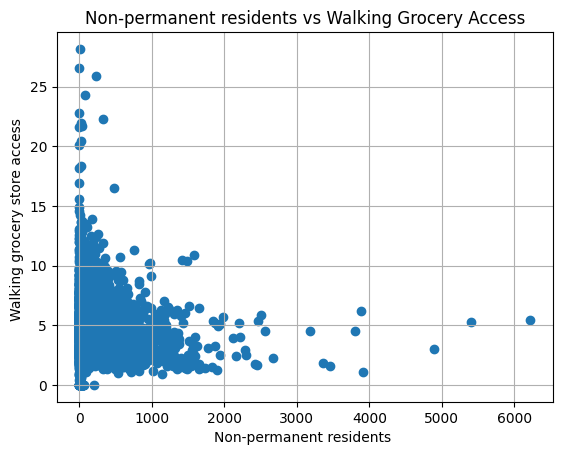

In [76]:
plt.scatter(merged['T1537'], merged['walk_gs'])
plt.xlabel('Non-permanent residents ')
plt.ylabel('Walking grocery store access ')
plt.title('Non-permanent residents vs Walking Grocery Access')
plt.grid(True)
plt.show()

In [77]:
corr_columns = [
    'T1537',               # Non-permanent residents
    'public_psef', 'walk_psef',  # Education access
    'public_hf', 'walk_hf',      # Healthcare access
    'public_emp', 'walk_emp',    # Employment access
    'public_gs', 'walk_gs',  # Grocery access
    'public_caf', 'walk_caf',    # Art access
    'public_srf', 'walk_srf'     # Sports access

]

In [78]:
corr = merged[corr_columns].corr()

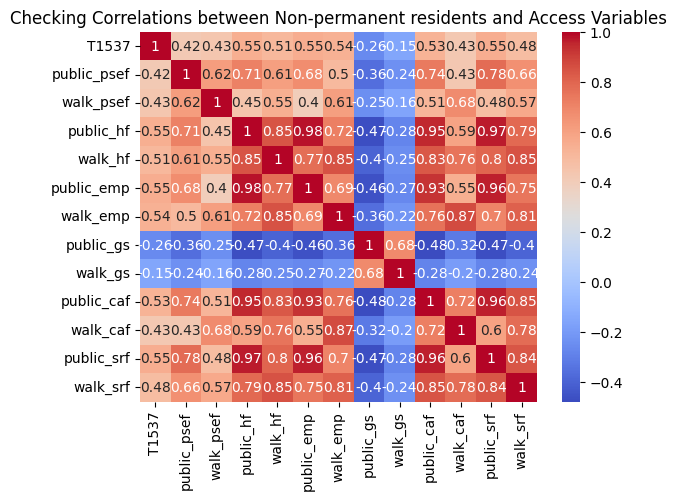

In [79]:

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Checking Correlations between Non-permanent residents and Access Variables')
plt.show()

# GROUPING BY REGION

In [80]:

def assign_region(row):
    if row['PRNAME'] in ['Ontario']:
        return 'Ontario'
    elif row['PRNAME'] in ['Alberta']:
        return 'Alberta\nAlberta'
    elif row['PRNAME'] in ['Quebec / Québec']:
        return 'Quebec\nQuébec'
    elif row['PRNAME'] in ['British Columbia / Colombie-Britannique']:
        return 'British Columbia\nColombie-Britannique'
    else:
        return 'Other'

merged['Region'] = merged.apply(assign_region, axis=1)

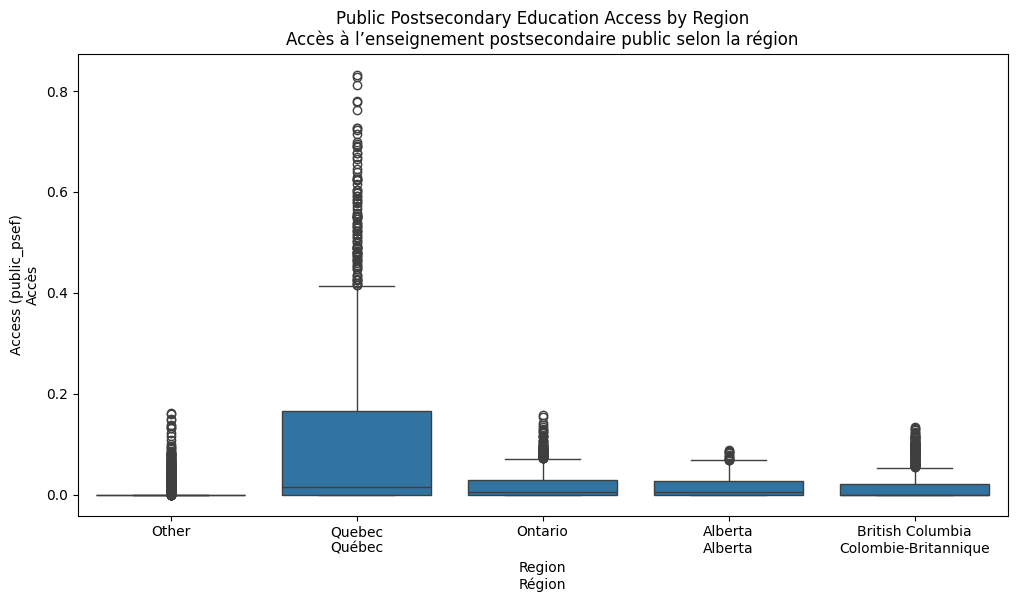

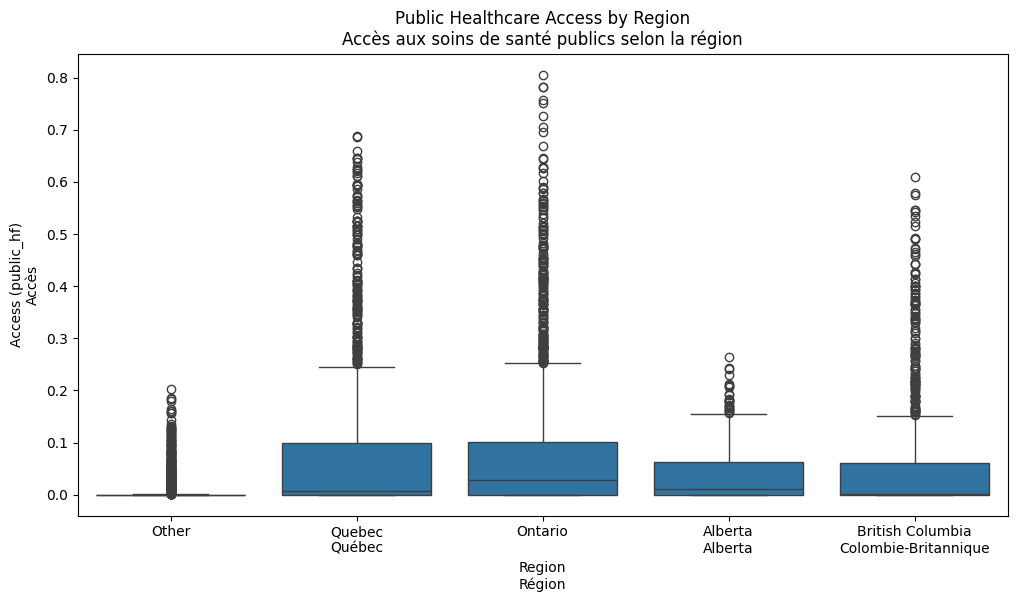

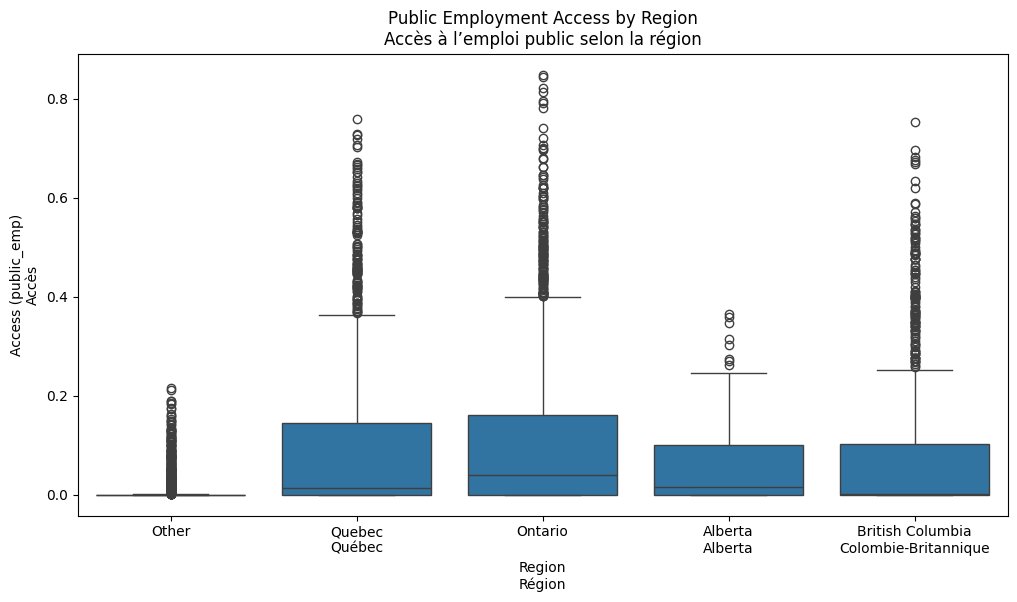

In [81]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='Region', y='public_psef', data=merged)
plt.title("Public Postsecondary Education Access by Region\nAccès à l’enseignement postsecondaire public selon la région")
plt.xlabel("Region\nRégion")
plt.ylabel("Access (public_psef)\nAccès")
plt.show()

plt.figure(figsize=(12, 6))
sns.boxplot(x='Region', y='public_hf', data=merged)
plt.title("Public Healthcare Access by Region\nAccès aux soins de santé publics selon la région")
plt.xlabel("Region\nRégion")
plt.ylabel("Access (public_hf)\nAccès")
plt.show()

plt.figure(figsize=(12, 6))
sns.boxplot(x='Region', y='public_emp', data=merged)
plt.title("Public Employment Access by Region\nAccès à l’emploi public selon la région")
plt.xlabel("Region\nRégion")
plt.ylabel("Access (public_emp)\nAccès")
plt.show()


# ACCESS TO RECREATION

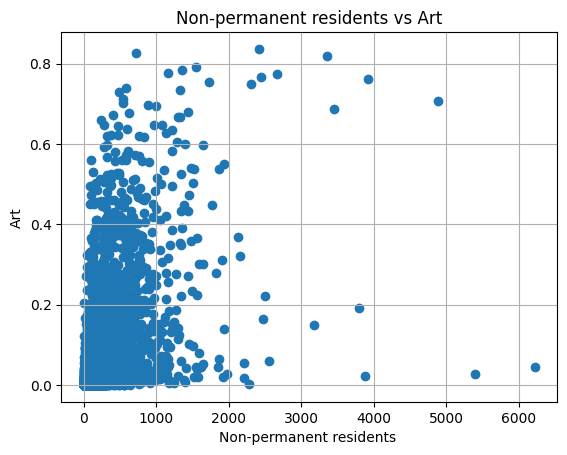

In [82]:
plt.scatter(merged['T1537'], merged['public_caf'])
plt.xlabel('Non-permanent residents ')
plt.ylabel('Art')
plt.title('Non-permanent residents vs Art')
plt.grid(True)
plt.show()

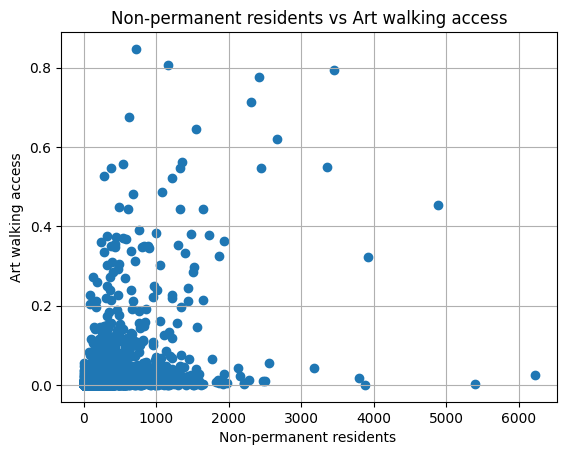

In [83]:
plt.scatter(merged['T1537'], merged['walk_caf'])
plt.xlabel('Non-permanent residents ')
plt.ylabel('Art walking access')
plt.title('Non-permanent residents vs Art walking access')
plt.grid(True)
plt.show()

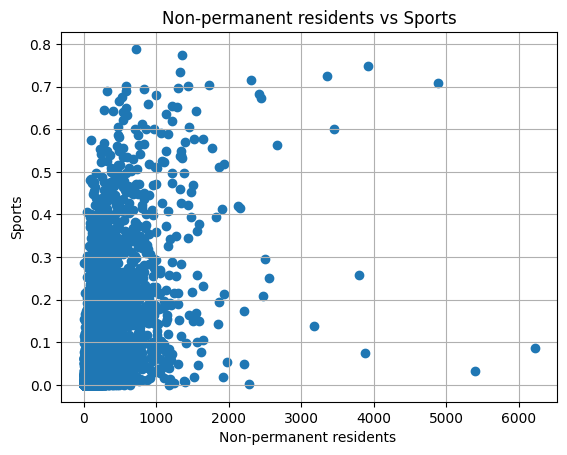

In [84]:
plt.scatter(merged['T1537'], merged['public_srf'])
plt.xlabel('Non-permanent residents ')
plt.ylabel('Sports')
plt.title('Non-permanent residents vs Sports')
plt.grid(True)
plt.show()

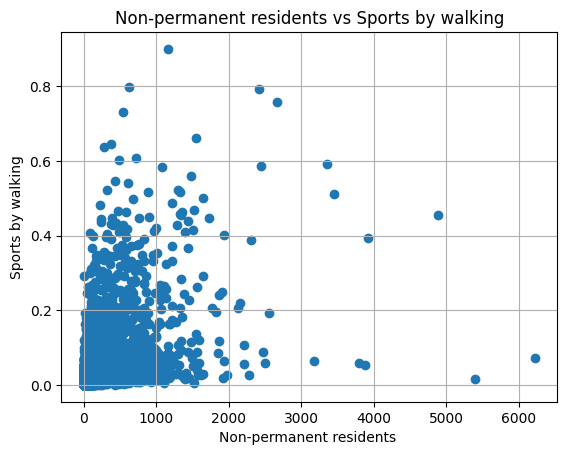

In [85]:
plt.scatter(merged['T1537'], merged['walk_srf'])
plt.xlabel('Non-permanent residents ')
plt.ylabel('Sports by walking')
plt.title('Non-permanent residents vs Sports by walking')
plt.grid(True)
plt.show()

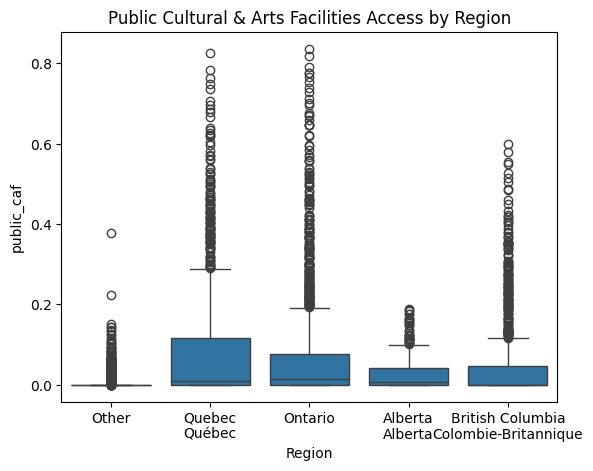

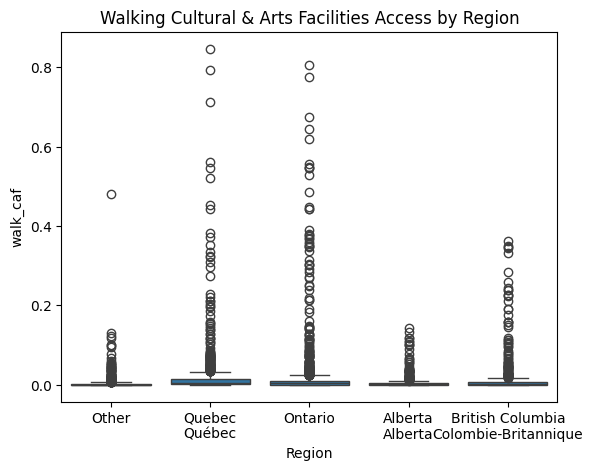

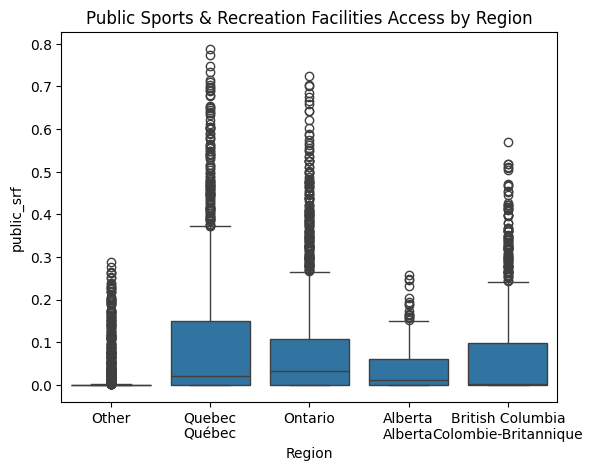

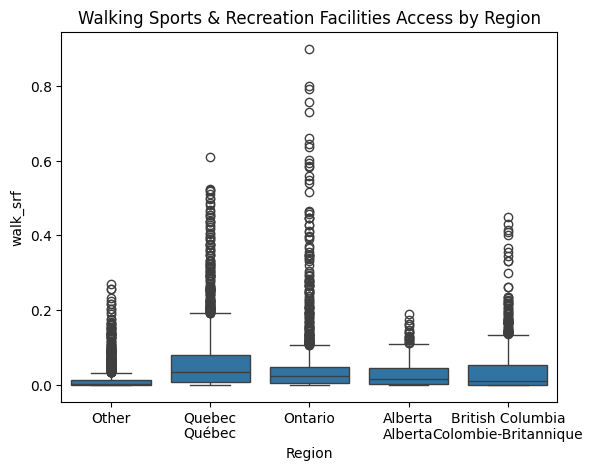

In [86]:

sns.boxplot(x='Region', y='public_caf', data=merged)
plt.title('Public Cultural & Arts Facilities Access by Region')
plt.show()

sns.boxplot(x='Region', y='walk_caf', data=merged)
plt.title('Walking Cultural & Arts Facilities Access by Region')
plt.show()


sns.boxplot(x='Region', y='public_srf', data=merged)
plt.title('Public Sports & Recreation Facilities Access by Region')
plt.show()

sns.boxplot(x='Region', y='walk_srf', data=merged)
plt.title('Walking Sports & Recreation Facilities Access by Region')
plt.show()

# FOCUSING ON ALBERTA AND EDMONTON

In [87]:
merged_alberta = merged[merged['PRNAME'] == 'Alberta']
merged_edmonton = merged[merged['CMANAME_x'] == 'Edmonton']
merged_alberta.head()

,CMANAME_x,CMAUID_x,CSDNAME_x,CSDUID_x,PRNAME,ada_code_n_x,ADA_code,T1527,T1528,T1529,...,public_srf,walk_caf,walk_ef,walk_emp,walk_gs,walk_hf,walk_psef,walk_srf,ada_code_n_y,Region
3792,Medicine Hat,805,Cypress County,4801003,Alberta,48010001,48010001,7215.0,6570.0,585.0,...,0.000003,0.000187,0.001428,0.000157,8.923700,0.000203,0.0,0.000475,48010001,Alberta\nAlberta
3793,Moderate metropolitan influenced zone (Alta.) ...,997,Forty Mile County No. 8,4801008,Alberta,48010002,48010002,5040.0,4060.0,970.0,...,0.000000,0.000088,0.004558,0.000304,NaN,0.000341,0.0,0.000029,48010002,Alberta\nAlberta
3794,Medicine Hat,805,Medicine Hat,4801006,Alberta,48010003,48010003,5935.0,5390.0,440.0,...,0.010187,0.000234,0.100393,0.011954,7.061518,0.012122,0.0,0.031194,48010003,Alberta\nAlberta
3795,Medicine Hat,805,Redcliff,4801018,Alberta,48010004,48010004,5540.0,4980.0,525.0,...,0.000000,0.000000,0.012754,0.003892,4.759757,0.000827,0.0,0.007890,48010004,Alberta\nAlberta
3796,Medicine Hat,805,Medicine Hat,4801006,Alberta,48010006,48010006,10075.0,9275.0,775.0,...,0.008863,0.000207,0.080218,0.006492,5.793640,0.012181,0.0,0.020827,48010006,Alberta\nAlberta


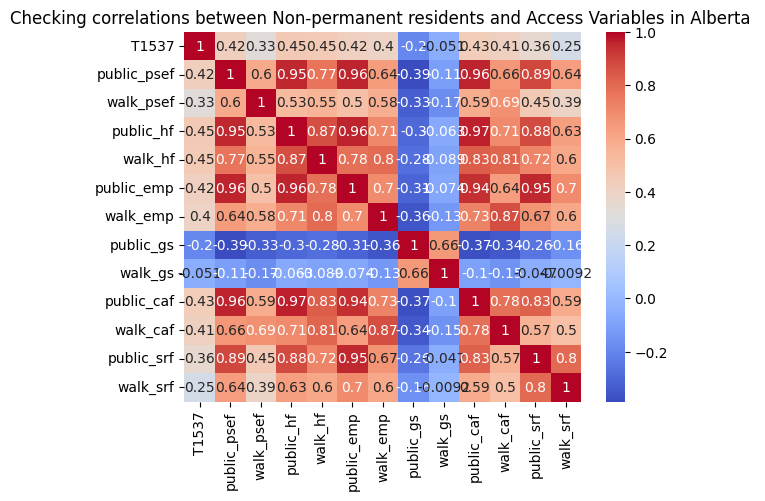

In [88]:
corr_alberta = merged_alberta[corr_columns].corr()

sns.heatmap(corr_alberta, annot=True, cmap='coolwarm', )
plt.title('Checking correlations between Non-permanent residents and Access Variables in Alberta ')
plt.show()

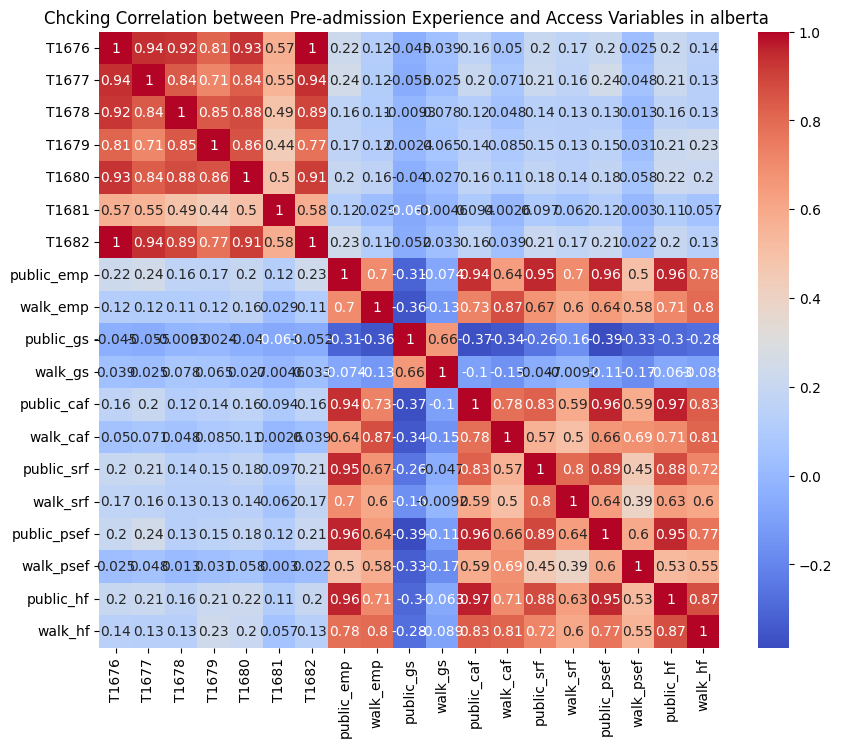

In [89]:

pre_adm_cols = [
    'T1676', 'T1677', 'T1678', 'T1679', 'T1680', 'T1681', 'T1682',
    'public_emp', 'walk_emp', 'public_gs', 'walk_gs', 'public_caf', 'walk_caf', 'public_srf', 'walk_srf', 'public_psef', 'walk_psef', 'public_hf', 'walk_hf'
]

corr_pre_adm_alberta = merged_alberta[pre_adm_cols].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr_pre_adm_alberta, annot=True, cmap='coolwarm',)
plt.title('Chcking Correlation between Pre-admission Experience and Access Variables in alberta ')
plt.show()

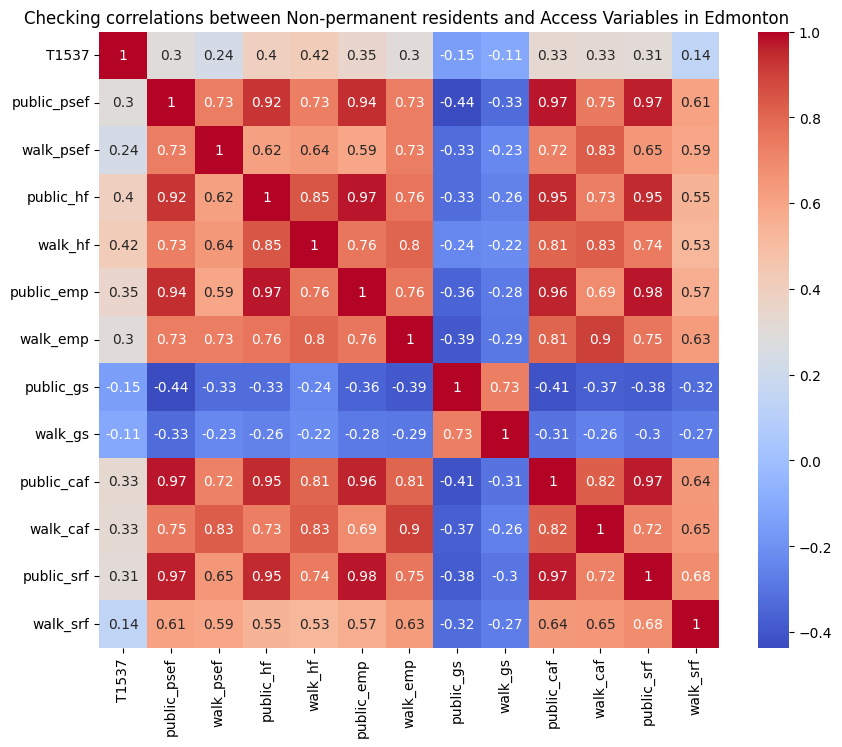

In [90]:
corr_edmonton = merged_edmonton[corr_columns].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr_edmonton, annot=True, cmap= 'coolwarm')
plt.title('Checking correlations between Non-permanent residents and Access Variables in Edmonton ')
plt.show()

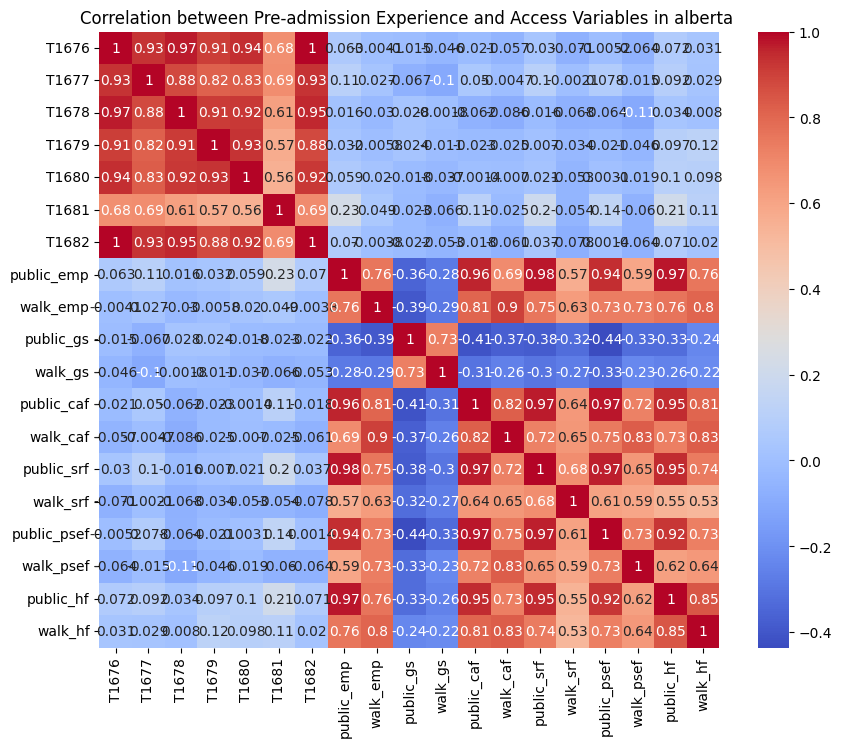

In [91]:

corr_pre_adm_edmonton = merged_edmonton[pre_adm_cols].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr_pre_adm_edmonton, annot=True, cmap='coolwarm')
plt.title('Correlation between Pre-admission Experience and Access Variables in alberta ')
plt.show()

#Comparing Regions

In [92]:
def assign_region_alberta (row):
    if row['CMANAME_x'] in ['Edmonton', 'Calgary']:
        return 'Major City'
    elif row['CMANAME_x'] in ['Lethbridge', 'Red Deer']:
        return 'Prairies City'
    else:
        return 'Prairies Rural'

merged_alberta['Region'] = merged_alberta.apply(assign_region_alberta, axis=1)

/var/folders/xm/q73q7tv51hn1gx79cbgnl5380000gn/T/ipykernel_47245/733923708.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_alberta['Region'] = merged_alberta.apply(assign_region_alberta, axis=1)


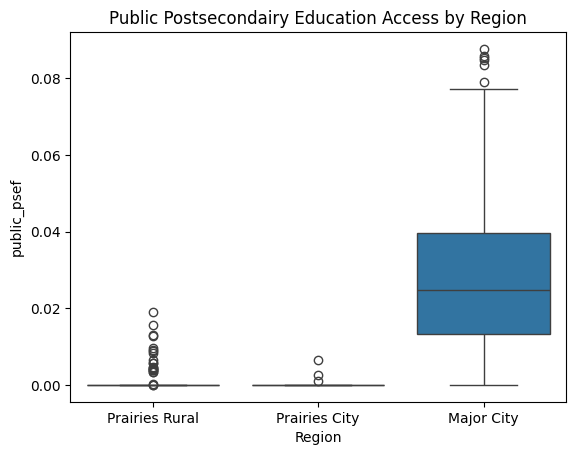

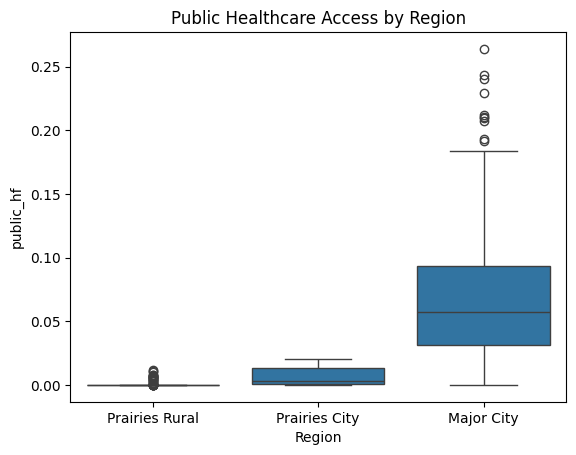

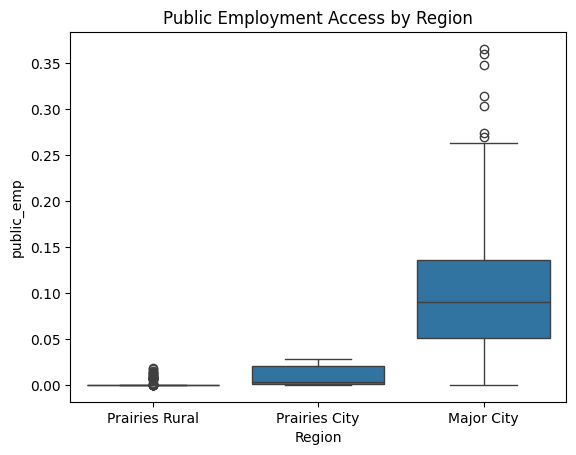

In [93]:


sns.boxplot(x='Region', y='public_psef', data=merged_alberta)
plt.title('Public Postsecondairy Education Access by Region')
plt.show()

sns.boxplot(x='Region', y='public_hf', data=merged_alberta)
plt.title('Public Healthcare Access by Region')
plt.show()

sns.boxplot(x='Region', y='public_emp', data=merged_alberta)
plt.title('Public Employment Access by Region')
plt.show()

# COMPARING RENT PRICES TO ACCESS

In [94]:
# Rent Data set gotten from Government of Alberta
df_rent = pd.read_csv('/content/download.csv')
df_rent.head()

FileNotFoundError: [Errno 2] No such file or directory: '/content/download.csv'

In [95]:

df_rent.columns = df_rent.columns.str.strip()

NameError: name 'df_rent' is not defined

In [96]:
# Filtering to latest year and a specific unit type
latest_year = df_rent['Period'].max()
df_filtered = df_rent[
    (df_rent['Period'] == latest_year) &
    (df_rent['IndicatorSummaryDescription'].str.contains('2-bedroom', case=False))
]

df_avg_rent = df_filtered.groupby('CSD', as_index=False)['OriginalValue'].mean()
df_avg_rent.rename(columns={'CSD': 'City', 'OriginalValue': 'AverageRent'}, inplace=True)


merged_alberta = merged_alberta.merge(df_avg_rent, how='left', left_on='CMANAME_x', right_on='City')


NameError: name 'df_rent' is not defined

In [ ]:
merged_alberta.head()

,CMANAME_x,CMAUID_x,CSDNAME_x,CSDUID_x,PRNAME,ada_code_n_x,ADA_code,T1527,T1528,T1529,...,walk_ef,walk_emp,walk_gs,walk_hf,walk_psef,walk_srf,ada_code_n_y,Region,City,AverageRent
0,Medicine Hat,805,Cypress County,4801003,Alberta,48010001,48010001,7215.0,6570.0,585.0,...,0.001428,0.000157,8.923700,0.000203,0.0,0.000475,48010001,Prairies Rural,Medicine Hat,1054.0425
1,Moderate metropolitan influenced zone (Alta.) ...,997,Forty Mile County No. 8,4801008,Alberta,48010002,48010002,5040.0,4060.0,970.0,...,0.004558,0.000304,NaN,0.000341,0.0,0.000029,48010002,Prairies Rural,NaN,NaN
2,Medicine Hat,805,Medicine Hat,4801006,Alberta,48010003,48010003,5935.0,5390.0,440.0,...,0.100393,0.011954,7.061518,0.012122,0.0,0.031194,48010003,Prairies Rural,Medicine Hat,1054.0425
3,Medicine Hat,805,Redcliff,4801018,Alberta,48010004,48010004,5540.0,4980.0,525.0,...,0.012754,0.003892,4.759757,0.000827,0.0,0.007890,48010004,Prairies Rural,Medicine Hat,1054.0425
4,Medicine Hat,805,Medicine Hat,4801006,Alberta,48010006,48010006,10075.0,9275.0,775.0,...,0.080218,0.006492,5.793640,0.012181,0.0,0.020827,48010006,Prairies Rural,Medicine Hat,1054.0425


In [ ]:
merged_alberta[['CMANAME_x', 'AverageRent_x']].head()
merged_alberta[['CMANAME_x', 'AverageRent_x']].tail()

KeyError: "['AverageRent_x'] not in index"

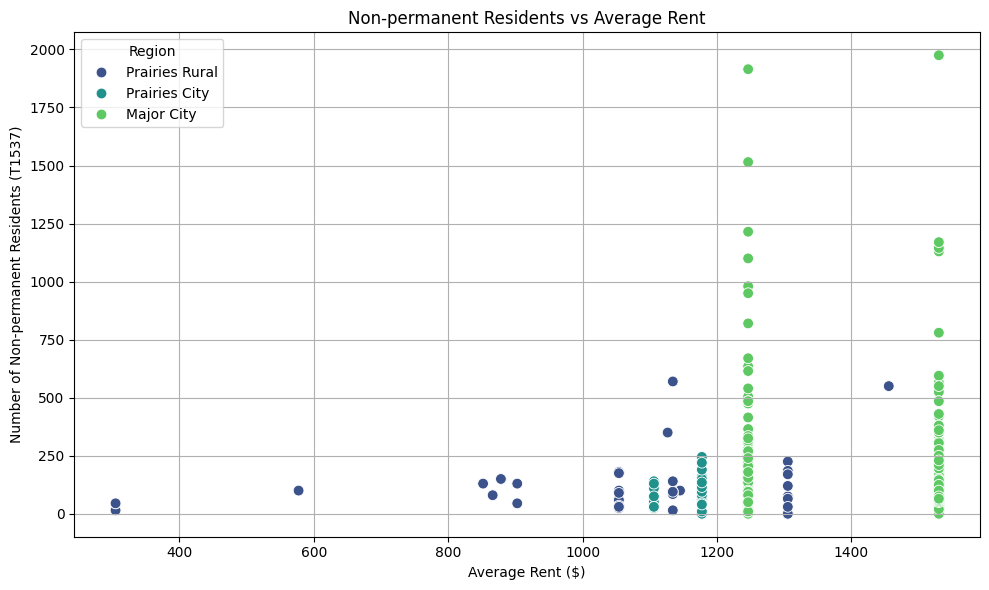

In [ ]:

plt.figure(figsize=(10,6))
sns.scatterplot(
    data=merged_alberta,
    x='AverageRent',
    y='T1537',
    hue='Region',
    palette='viridis',
    s=60
)

plt.title('Non-permanent Residents vs Average Rent')
plt.xlabel('Average Rent ($)')
plt.ylabel('Number of Non-permanent Residents (T1537)')
plt.grid(True)
plt.tight_layout()
plt.show()

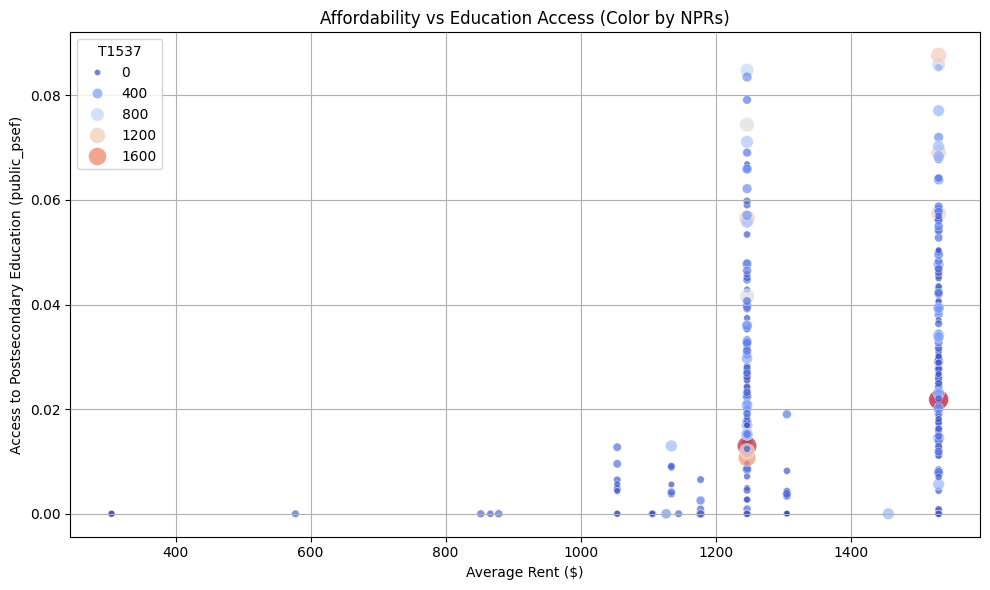

In [ ]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=merged_alberta,
    x='AverageRent',
    y='public_psef',
    size='T1537',
    hue='T1537',
    palette='coolwarm',
    sizes=(20, 200),
    alpha=0.7
)

plt.title('Affordability vs Education Access (Color by NPRs)')
plt.xlabel('Average Rent ($)')
plt.ylabel('Access to Postsecondary Education (public_psef)')
plt.grid(True)
plt.tight_layout()
plt.show()